In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load data
df = pd.read_csv('/kaggle/input/datasets/lakshmideepikapeyala/bank-churn/Churn_Modelling.csv')
print(df.shape)
df.head()



(10000, 14)


,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [6]:
# Basic info & missing values
df.info()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


RowNumber          0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

In [7]:
# Drop columns not useful for analysis
df.drop(['RowNumber', 'CustomerId', 'Surname'], axis=1, inplace=True)
df.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [8]:
churn_rate = df['Exited'].mean() * 100
print(f"Overall Churn Rate: {churn_rate:.2f}%")

Overall Churn Rate: 20.37%


Geography
France     16.154767
Germany    32.443204
Spain      16.673395
Name: Exited, dtype: float64


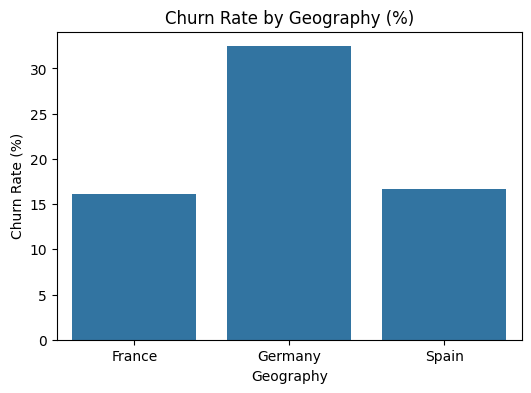

In [9]:
geo_churn = df.groupby('Geography')['Exited'].mean() * 100
print(geo_churn)

plt.figure(figsize=(6,4))
sns.barplot(x=geo_churn.index, y=geo_churn.values)
plt.title('Churn Rate by Geography (%)')
plt.ylabel('Churn Rate (%)')
plt.show()

In [10]:
gender_churn = df.groupby('Gender')['Exited'].mean() * 100
print(gender_churn)

Gender
Female    25.071539
Male      16.455928
Name: Exited, dtype: float64


AgeGroup
18-30     7.502569
31-40    12.087171
41-50    33.965517
51-60    56.210790
60+      24.784483
Name: Exited, dtype: float64


/tmp/ipykernel_58/3021930689.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_churn = df.groupby('AgeGroup')['Exited'].mean() * 100


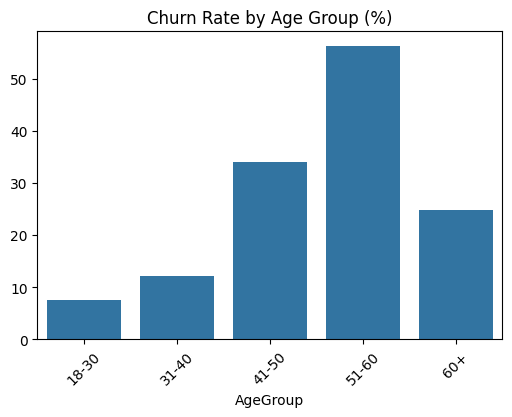

In [11]:
df['AgeGroup'] = pd.cut(df['Age'], bins=[18,30,40,50,60,100],
                         labels=['18-30','31-40','41-50','51-60','60+'])
age_churn = df.groupby('AgeGroup')['Exited'].mean() * 100
print(age_churn)

plt.figure(figsize=(6,4))
sns.barplot(x=age_churn.index, y=age_churn.values)
plt.title('Churn Rate by Age Group (%)')
plt.xticks(rotation=45)
plt.show()

In [12]:
product_churn = df.groupby('NumOfProducts')['Exited'].mean() * 100
print(product_churn)

NumOfProducts
1     27.714398
2      7.581699
3     82.706767
4    100.000000
Name: Exited, dtype: float64


In [13]:
active_churn = df.groupby('IsActiveMember')['Exited'].mean() * 100
print(active_churn)

IsActiveMember
0    26.850897
1    14.269074
Name: Exited, dtype: float64


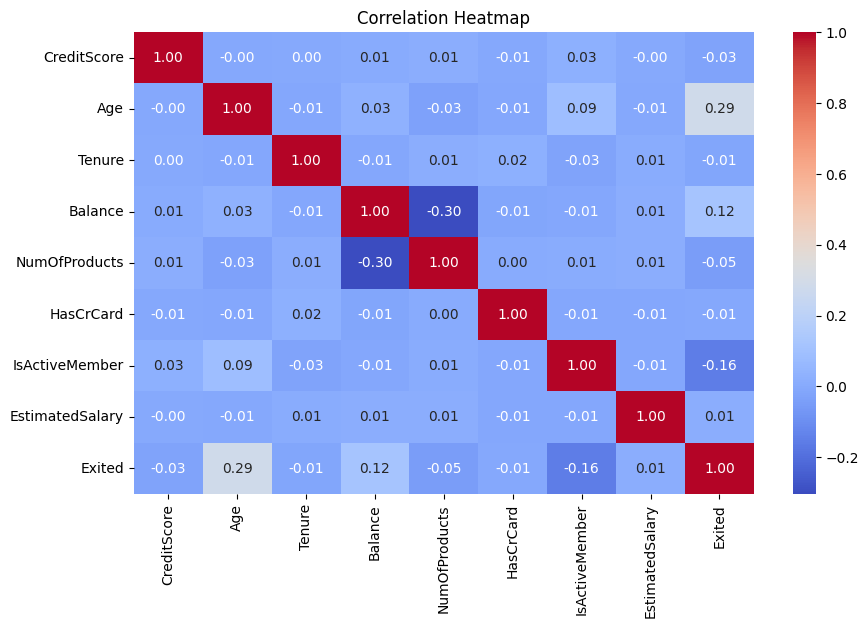

In [14]:
plt.figure(figsize=(10,6))
sns.heatmap(df.select_dtypes(include=np.number).corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

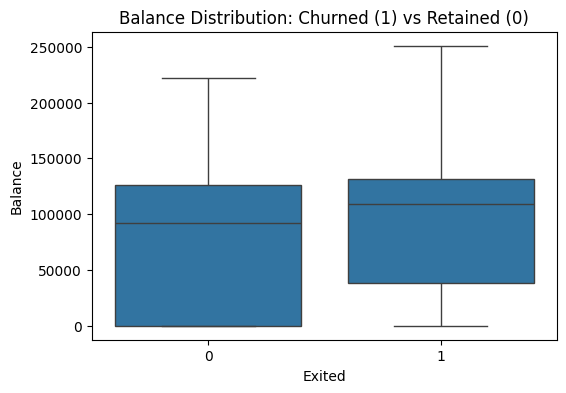

In [15]:
plt.figure(figsize=(6,4))
sns.boxplot(x='Exited', y='Balance', data=df)
plt.title('Balance Distribution: Churned (1) vs Retained (0)')
plt.show()

In [17]:
df.to_csv('bank_churn_cleaned.csv', index=False)
print("Cleaned file saved: bank_churn_cleaned.csv")

Cleaned file saved: bank_churn_cleaned.csv
